# Treasury Multi-Curve: Bond Curve vs SOFR vs Repo

**The real-world setup:** a Treasury desk uses three curves simultaneously.

1. **Treasury curve** — bootstrapped from on-the-run bond prices (what the bond market says)
2. **SOFR/OIS curve** — bootstrapped from swap rates (what the derivatives market says)
3. **Repo curve** — from repo market quotes (what financing costs)

The spreads between these curves are where trading opportunities live.

Market data modelled on **15 Jul 2024** — realistic levels for an inverted US yield curve environment.

In [1]:
import sys, os, math
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "python"))

import numpy as np
import pandas as pd
from datetime import date
from dateutil.relativedelta import relativedelta

from pricebook.bond import FixedRateBond
from pricebook.bootstrap import bootstrap
from pricebook.bond_desk import fit_curve_from_bonds
from pricebook.bond_trading_desk import bond_risk_metrics, bond_carry_roll
from pricebook.repo_curve import build_repo_curve, repo_carry_from_curve
from pricebook.treasury_quoting import to_32nds
from pricebook.viz import configure_theme, greeks_profile
from pricebook.viz._backend import apply_theme, create_figure

configure_theme(seaborn_style="whitegrid", seaborn_context="notebook")

REF = date(2024, 7, 15)
print(f"Valuation date: {REF}\n")

Valuation date: 2024-07-15



## 1. Build the three curves from market data

In [2]:
# ═══════════════════════════════════════════════════════════════
# CURVE 1: Treasury curve — from on-the-run bond market prices
# ═══════════════════════════════════════════════════════════════

# On-the-run Treasury notes: coupon, issue date, maturity, market clean price
# Prices reflect Jul 2024 inverted curve (short yields > long yields)
ust_bonds = [
    ("2Y",  0.0475, date(2024, 6, 30), date(2026, 6, 30),  99.750),
    ("3Y",  0.0450, date(2024, 5, 15), date(2027, 5, 15),  99.375),
    ("5Y",  0.0425, date(2024, 4, 30), date(2029, 4, 30),  99.000),
    ("7Y",  0.0400, date(2024, 3, 31), date(2031, 3, 31),  97.500),
    ("10Y", 0.0425, date(2024, 2, 15), date(2034, 2, 15), 102.500),
    ("20Y", 0.0450, date(2024, 2, 15), date(2044, 2, 15),  99.250),
    ("30Y", 0.0437, date(2024, 2, 15), date(2054, 2, 15),  96.000),
]

bonds_and_prices = []
for label, coupon, issue, mat, clean_px in ust_bonds:
    bond = FixedRateBond.treasury_note(issue, mat, coupon)
    bonds_and_prices.append((bond, clean_px))

treasury_curve, fitted_bonds = fit_curve_from_bonds(REF, bonds_and_prices)

print("CURVE 1: Treasury Discount Curve (from bond prices)")
print(f"{'Tenor':>5}  {'Coupon':>7}  {'MktPrice':>9}  {'FitPrice':>9}  {'Resid':>7}  {'Zero':>7}")
print(f"{'─'*5}  {'─'*7}  {'─'*9}  {'─'*9}  {'─'*7}  {'─'*7}")
for (label, cpn, issue, mat, mkt_px), fb in zip(ust_bonds, fitted_bonds):
    T = (mat - REF).days / 365.25
    zero = treasury_curve.zero_rate(mat)
    print(f"{label:>5}  {cpn*100:>6.2f}%  {mkt_px:>9.3f}  {fb.fitted_price:>9.3f}  {fb.residual:>+6.3f}  {zero*100:>6.2f}%")

# ═══════════════════════════════════════════════════════════════
# CURVE 2: SOFR/OIS curve — from swap market
# ═══════════════════════════════════════════════════════════════

deposits = [
    (REF + relativedelta(months=1), 0.0533),
    (REF + relativedelta(months=3), 0.0531),
    (REF + relativedelta(months=6), 0.0518),
]
swaps = [
    (REF + relativedelta(years=1), 0.0495),
    (REF + relativedelta(years=2), 0.0460),
    (REF + relativedelta(years=3), 0.0440),
    (REF + relativedelta(years=5), 0.0415),
    (REF + relativedelta(years=7), 0.0405),
    (REF + relativedelta(years=10), 0.0395),
    (REF + relativedelta(years=20), 0.0410),
    (REF + relativedelta(years=30), 0.0420),
]
sofr_curve = bootstrap(REF, deposits, swaps)
print("\nCURVE 2: SOFR/OIS Curve (from swaps) — built")

# ═══════════════════════════════════════════════════════════════
# CURVE 3: Repo curve — from repo market
# ═══════════════════════════════════════════════════════════════

repo_curve = build_repo_curve(REF, {
    "ON": 0.0532, "1W": 0.0530, "1M": 0.0528,
    "3M": 0.0523, "6M": 0.0515, "1Y": 0.0495,
})
print("CURVE 3: GC Repo Curve (from repo market) — built")

CURVE 1: Treasury Discount Curve (from bond prices)
Tenor   Coupon   MktPrice   FitPrice    Resid     Zero
─────  ───────  ─────────  ─────────  ───────  ───────
   2Y    4.75%     99.750     99.750  +0.000    4.83%
   3Y    4.50%     99.375     99.375  +0.000    4.67%
   5Y    4.25%     99.000     99.000  +0.000    4.41%
   7Y    4.00%     97.500     97.500  +0.000    4.37%
  10Y    4.25%    102.500    102.500  +0.000    3.81%
  20Y    4.50%     99.250     99.250  +0.000    4.63%
  30Y    4.37%     96.000     96.000  +0.000    4.68%

CURVE 2: SOFR/OIS Curve (from swaps) — built
CURVE 3: GC Repo Curve (from repo market) — built


## 2. Compare the three curves — where are the spreads?


 Tenor   Treasury       SOFR       Repo   TSY-SOFR
──────  ─────────  ─────────  ─────────  ─────────
 0.25Y      4.83%      5.35%      5.23%    -52.2bp
  0.5Y      4.83%      5.18%      5.15%    -35.8bp
    1Y      4.83%      4.89%      4.95%     -6.0bp
    2Y      4.82%      4.54%      4.95%    +27.8bp
    3Y      4.64%      4.34%      4.95%    +30.2bp
    5Y      4.41%      4.08%      4.95%    +32.7bp
    7Y      4.29%      3.98%          —    +31.0bp
   10Y      3.87%      3.88%          —     -0.2bp
   20Y      4.63%      4.07%          —    +55.4bp
   30Y      4.69%      4.23%          —    +45.9bp


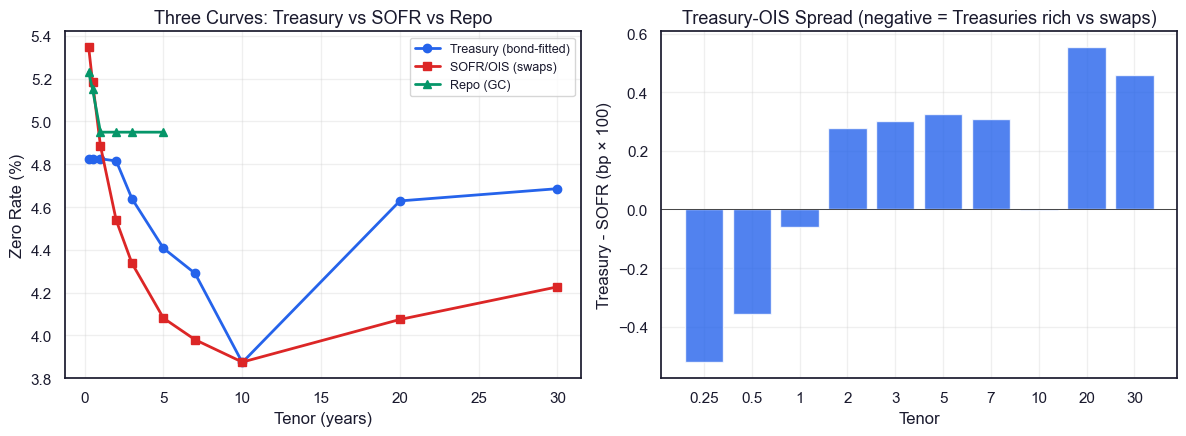

In [3]:
# Zero rates from all three curves at standard tenors
tenors = [0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
tsy_zeros, sofr_zeros, repo_zeros = [], [], []

for t in tenors:
    d = REF + relativedelta(months=int(t * 12)) if t < 1 else REF + relativedelta(years=int(t))
    tsy_zeros.append(treasury_curve.zero_rate(d) * 100)
    sofr_zeros.append(sofr_curve.zero_rate(d) * 100)
    repo_zeros.append(repo_curve.rate_at(int(t * 365)) * 100)

# Plot all three curves
with apply_theme():
    fig, (ax1, ax2) = create_figure(2)

    ax1.plot(tenors, tsy_zeros, 'o-', linewidth=2, label="Treasury (bond-fitted)")
    ax1.plot(tenors, sofr_zeros, 's-', linewidth=2, label="SOFR/OIS (swaps)")
    ax1.plot(tenors[:6], repo_zeros[:6], '^-', linewidth=2, label="Repo (GC)")
    ax1.set_xlabel("Tenor (years)")
    ax1.set_ylabel("Zero Rate (%)")
    ax1.set_title("Three Curves: Treasury vs SOFR vs Repo")
    ax1.legend(fontsize=9)

    # Treasury-OIS spread (the basis trade signal)
    tsy_ois_spread = [t - s for t, s in zip(tsy_zeros, sofr_zeros)]
    ax2.bar([f"{t}" for t in tenors], tsy_ois_spread, alpha=0.8)
    ax2.axhline(0, color='black', linewidth=0.5)
    ax2.set_xlabel("Tenor")
    ax2.set_ylabel("Treasury - SOFR (bp × 100)")
    ax2.set_title("Treasury-OIS Spread (negative = Treasuries rich vs swaps)")

    fig.tight_layout()

# Table
print(f"\n{'Tenor':>6}  {'Treasury':>9}  {'SOFR':>9}  {'Repo':>9}  {'TSY-SOFR':>9}")
print(f"{'─'*6}  {'─'*9}  {'─'*9}  {'─'*9}  {'─'*9}")
for i, t in enumerate(tenors):
    repo_str = f"{repo_zeros[i]:.2f}%" if i < 6 else "—"
    spread = tsy_zeros[i] - sofr_zeros[i]
    print(f"{t:>5}Y  {tsy_zeros[i]:>8.2f}%  {sofr_zeros[i]:>8.2f}%  {repo_str:>9}  {spread*100:>+7.1f}bp")

### Curve Construction Summary

| Curve | Inputs | Method | Use |
|-------|--------|--------|-----|
| **Treasury** | Bond clean prices (any number) | Sequential bootstrap via `fit_curve_from_bonds` — solves for each discount factor by maturity | Fair value in the cash bond market |
| **SOFR/OIS** | Deposit rates + swap rates | Bootstrap via `bootstrap` — deposits for short end, swaps for long end | Fair value in the derivatives market |
| **Repo** | Direct market quotes (ON, 1W, 1M, ...) | Linear interpolation via `build_repo_curve` — no bootstrapping needed | Financing cost for holding bonds |

**Key relationships:**
- **Treasury - SOFR spread** → basis trade signal (are bonds rich or cheap vs swaps?)
- **Coupon - Repo** → net carry (do you earn or pay to hold?)
- **Forward rates** → implied by any curve via no-arbitrage: `curve.forward_rate(d1, d2)`
- More bonds → more pillar points → smoother curve with better interpolation
- SOFR overnight ≈ GC repo overnight (same collateral, same market)

## 3. Price the same bond off each curve — what's the difference?

In [4]:
# Take the 10Y on-the-run note
bond_10y = bonds_and_prices[4][0]  # 4.25% Feb 2034
mkt_clean = ust_bonds[4][4]        # 102.500
settle = bond_10y.settlement_date(REF)
ai = bond_10y.accrued_interest(settle)

# Price off each curve
price_tsy = bond_10y.dirty_price(treasury_curve)
price_sofr = bond_10y.dirty_price(sofr_curve)
ytm_tsy = bond_10y.yield_to_maturity(price_tsy, settle)
ytm_sofr = bond_10y.yield_to_maturity(price_sofr, settle)
ytm_mkt = bond_10y.yield_to_maturity(mkt_clean + ai, settle)

print("10Y T-Note: 4.25% due Feb 2034")
print(f"  Market clean price: {mkt_clean:.3f} ({to_32nds(mkt_clean)})")
print(f"  Accrued interest:   {ai:.4f}")
print()
print(f"{'Curve':<20}  {'Dirty Price':>11}  {'Clean':>11}  {'YTM':>8}  {'vs Market':>10}")
print(f"{'─'*20}  {'─'*11}  {'─'*11}  {'─'*8}  {'─'*10}")
print(f"{'Market':<20}  {mkt_clean + ai:>11.4f}  {mkt_clean:>11.3f}  {ytm_mkt*100:>7.3f}%  {'—':>10}")
print(f"{'Treasury curve':<20}  {price_tsy:>11.4f}  {price_tsy - ai:>11.3f}  {ytm_tsy*100:>7.3f}%  {(price_tsy - mkt_clean - ai) * 100:>+8.1f}ct")
print(f"{'SOFR/OIS curve':<20}  {price_sofr:>11.4f}  {price_sofr - ai:>11.3f}  {ytm_sofr*100:>7.3f}%  {(price_sofr - mkt_clean - ai) * 100:>+8.1f}ct")

print(f"\nTreasury-SOFR price difference: {(price_tsy - price_sofr) * 100:+.1f} cents")
print(f"Treasury-SOFR yield spread:     {(ytm_tsy - ytm_sofr) * 1e4:+.1f}bp")
print(f"\nInterpretation:")
if price_tsy > price_sofr:
    print(f"  Treasury curve gives HIGHER price → Treasuries are RICH vs SOFR")
    print(f"  Trade: pay fixed in swaps + buy Treasuries (basis tightener)")
else:
    print(f"  Treasury curve gives LOWER price → Treasuries are CHEAP vs SOFR")
    print(f"  Trade: receive fixed in swaps + sell Treasuries (basis widener)")

10Y T-Note: 4.25% due Feb 2034
  Market clean price: 102.500 (102-16)
  Accrued interest:   1.7699

Curve                 Dirty Price        Clean       YTM   vs Market
────────────────────  ───────────  ───────────  ────────  ──────────
Market                   104.2699      102.500    3.934%           —
Treasury curve           104.2582      102.488    3.936%      -1.2ct
SOFR/OIS curve           104.0542      102.284    3.961%     -21.6ct

Treasury-SOFR price difference: +20.4 cents
Treasury-SOFR yield spread:     -2.5bp

Interpretation:
  Treasury curve gives HIGHER price → Treasuries are RICH vs SOFR
  Trade: pay fixed in swaps + buy Treasuries (basis tightener)


## 4. Carry analysis — what does it cost to hold the position?

In [5]:
# Carry from each financing source
face = 10_000_000  # $10M position

# 1. Carry using repo curve (term-matched)
repo_carry = repo_carry_from_curve(price_tsy, bond_10y.coupon_rate, repo_curve, hold_days=30)

# 2. Carry using flat SOFR rate
sofr_1m = sofr_curve.zero_rate(REF + relativedelta(months=1))

# 3. Carry using bond_carry_roll (from bond desk)
desk_carry = bond_carry_roll(bond_10y, treasury_curve, repo_rate=repo_carry.repo_rate_used,
                              horizon_days=30, settlement=settle)

print("10Y T-Note Carry Analysis ($10M, 30-day horizon)")
print(f"{'─'*60}")
print(f"  Bond coupon:       {bond_10y.coupon_rate*100:.2f}% → ${bond_10y.coupon_rate * face * 30 / 365:>+10,.0f}")
print(f"  Repo rate (1M):    {repo_carry.repo_rate_used*100:.2f}% → ${repo_carry.repo_cost * face / 100:>+10,.0f}")
print(f"  SOFR rate (1M):    {sofr_1m*100:.2f}%")
print(f"  Net carry (repo):  ${repo_carry.net_carry * face / 100:>+10,.0f}")
print(f"  Annualised:        {repo_carry.annualised_carry_bps:+.0f}bp")
print(f"{'─'*60}")

# Carry at different repo tenors
print(f"\nCarry by repo tenor:")
print(f"{'Tenor':>6}  {'Repo Rate':>9}  {'Net Carry':>12}  {'Ann (bp)':>9}")
print(f"{'─'*6}  {'─'*9}  {'─'*12}  {'─'*9}")
for label, days in [("O/N", 1), ("1W", 7), ("1M", 30), ("3M", 91)]:
    rc = repo_carry_from_curve(price_tsy, bond_10y.coupon_rate, repo_curve, hold_days=days)
    print(f"{label:>6}  {rc.repo_rate_used*100:>8.2f}%  ${rc.net_carry * face / 100:>+11,.0f}  {rc.annualised_carry_bps:>+8.0f}bp")

print(f"\nInverted curve environment: short-term repo ({repo_carry.repo_rate_used*100:.0f}bp) > bond coupon ({bond_10y.coupon_rate*100:.0f}bp)")
print(f"→ NEGATIVE carry: you PAY to hold this bond. Roll-down must compensate.")

10Y T-Note Carry Analysis ($10M, 30-day horizon)
────────────────────────────────────────────────────────────
  Bond coupon:       4.25% → $   +34,932
  Repo rate (1M):    5.28% → $   +45,874
  SOFR rate (1M):    5.39%
  Net carry (repo):  $   -10,942
  Annualised:        -128bp
────────────────────────────────────────────────────────────

Carry by repo tenor:
 Tenor  Repo Rate     Net Carry   Ann (bp)
──────  ─────────  ────────────  ─────────
   O/N      5.32%  $       -376      -132bp
    1W      5.30%  $     -2,594      -130bp
    1M      5.28%  $    -10,942      -128bp
    3M      5.23%  $    -31,873      -123bp

Inverted curve environment: short-term repo (5bp) > bond coupon (4bp)
→ NEGATIVE carry: you PAY to hold this bond. Roll-down must compensate.


## Summary

| Curve | Source | What it tells you |
|-------|--------|-------------------|
| **Treasury** | On-the-run bond prices | Fair value in the bond market |
| **SOFR/OIS** | Swap rates | Fair value in the derivatives market |
| **Repo** | Repo market | Financing cost for holding bonds |

| Spread | Signal |
|--------|--------|
| **Treasury - SOFR** | Basis trade: are Treasuries rich or cheap vs swaps? |
| **Coupon - Repo** | Carry: do you earn or pay to hold? |
| **Roll-down** | Curve steepness: does aging help? |

In an inverted curve (Jul 2024): negative carry everywhere, but long-end roll-down partially compensates. The basis (Treasury vs SOFR) drives relative value between cash and derivatives.

## 5. Quick-start: 30 bonds + SOFR only

Minimal setup when you have a universe of Treasury bonds and SOFR quotes — no repo data needed.

In [6]:
# ═══════════════════════════════════════════════════════════════
# STEP 1: Define your bond universe (30 on-the-run + off-the-run)
# ═══════════════════════════════════════════════════════════════
# Format: (label, coupon, issue_date, maturity_date, market_clean_price)

bond_universe = [
    # Short end (bills priced as zero-coupon via small coupon proxy)
    ("0.5Y",  0.0000, date(2024, 1, 18), date(2024, 12, 15),  97.375),
    ("1Y",    0.0475, date(2023, 7, 15), date(2025, 7, 15),   99.875),
    # 2Y sector
    ("2Y OTR",  0.0475, date(2024, 6, 30), date(2026, 6, 30),  99.750),
    ("2Y OFR",  0.0400, date(2023, 6, 30), date(2025, 6, 30),  99.125),
    ("2.5Y",    0.0425, date(2024, 1, 15), date(2027, 1, 15),  99.250),
    # 3Y sector
    ("3Y OTR",  0.0450, date(2024, 5, 15), date(2027, 5, 15),  99.375),
    ("3Y OFR",  0.0375, date(2023, 5, 15), date(2026, 5, 15),  98.875),
    ("3.5Y",    0.0400, date(2024, 1, 15), date(2027, 7, 15),  98.750),
    # 5Y sector
    ("5Y OTR",  0.0425, date(2024, 4, 30), date(2029, 4, 30),  99.000),
    ("5Y OFR",  0.0350, date(2023, 4, 30), date(2028, 4, 30),  97.500),
    ("4Y",      0.0400, date(2024, 3, 15), date(2028, 3, 15),  98.500),
    ("6Y",      0.0375, date(2024, 1, 15), date(2030, 1, 15),  97.000),
    # 7Y sector
    ("7Y OTR",  0.0400, date(2024, 3, 31), date(2031, 3, 31),  97.500),
    ("7Y OFR",  0.0325, date(2023, 3, 31), date(2030, 3, 31),  95.750),
    ("8Y",      0.0375, date(2024, 2, 15), date(2032, 2, 15),  96.500),
    # 10Y sector
    ("10Y OTR", 0.0425, date(2024, 2, 15), date(2034, 2, 15), 102.500),
    ("10Y OFR", 0.0350, date(2023, 2, 15), date(2033, 2, 15),  97.250),
    ("9Y",      0.0375, date(2024, 1, 15), date(2033, 1, 15),  96.875),
    # Long end
    ("15Y",     0.0400, date(2024, 2, 15), date(2039, 2, 15),  95.500),
    ("20Y OTR", 0.0450, date(2024, 2, 15), date(2044, 2, 15),  99.250),
    ("20Y OFR", 0.0375, date(2023, 2, 15), date(2043, 2, 15),  92.750),
    ("25Y",     0.0425, date(2024, 2, 15), date(2049, 2, 15),  96.000),
    ("30Y OTR", 0.0437, date(2024, 2, 15), date(2054, 2, 15),  96.000),
    ("30Y OFR", 0.0375, date(2023, 2, 15), date(2053, 2, 15),  87.500),
    # Fill in extra off-the-runs for density
    ("1.5Y",    0.0450, date(2023, 1, 15), date(2025, 12, 15),  99.500),
    ("2.75Y",   0.0400, date(2023, 10, 15), date(2026, 10, 15), 99.000),
    ("4.5Y",    0.0375, date(2023, 7, 15), date(2028, 7, 15),   97.750),
    ("5.5Y",    0.0350, date(2023, 10, 15), date(2029, 10, 15), 96.500),
    ("12Y",     0.0400, date(2023, 8, 15), date(2035, 8, 15),   97.500),
    ("17Y",     0.0425, date(2023, 5, 15), date(2041, 5, 15),   96.250),
]

print(f"Bond universe: {len(bond_universe)} issues")

Bond universe: 30 issues


In [7]:
# ═══════════════════════════════════════════════════════════════
# STEP 2: Build Treasury curve from the 30 bonds
# ═══════════════════════════════════════════════════════════════

bonds_30 = []
labels_30 = []
for label, coupon, issue, mat, clean_px in bond_universe:
    bond = FixedRateBond.treasury_note(issue, mat, coupon)
    bonds_30.append((bond, clean_px))
    labels_30.append(label)

tsy_curve_30, fitted_30 = fit_curve_from_bonds(REF, bonds_30)

print(f"Treasury curve bootstrapped from {len(bonds_30)} bonds")
print(f"\n{'Label':>10}  {'Coupon':>7}  {'Maturity':>12}  {'MktPx':>8}  {'FitPx':>8}  {'Resid':>7}  {'Zero':>7}")
print(f"{'─'*10}  {'─'*7}  {'─'*12}  {'─'*8}  {'─'*8}  {'─'*7}  {'─'*7}")

# fitted_30 is sorted by maturity — match back to labels
sorted_universe = sorted(bond_universe, key=lambda x: x[3])
for (label, cpn, issue, mat, mkt_px), fb in zip(sorted_universe, fitted_30):
    zero = tsy_curve_30.zero_rate(mat)
    print(f"{label:>10}  {cpn*100:>6.2f}%  {mat.isoformat():>12}  {mkt_px:>8.3f}  {fb.fitted_price:>8.3f}  {fb.residual:>+6.3f}  {zero*100:>6.2f}%")

Treasury curve bootstrapped from 30 bonds

     Label   Coupon      Maturity     MktPx     FitPx    Resid     Zero
──────────  ───────  ────────────  ────────  ────────  ───────  ───────
      0.5Y    0.00%    2024-12-15    97.375    97.375  +0.000    6.35%
    2Y OFR    4.00%    2025-06-30    99.125    99.125  -0.000    4.87%
        1Y    4.75%    2025-07-15    99.875    99.875  +0.000    4.81%
      1.5Y    4.50%    2025-12-15    99.500    99.500  +0.000    4.80%
    3Y OFR    3.75%    2026-05-15    98.875    98.875  +0.000    4.33%
    2Y OTR    4.75%    2026-06-30    99.750    99.750  +0.000    4.82%
     2.75Y    4.00%    2026-10-15    99.000    99.000  +0.000    4.41%
      2.5Y    4.25%    2027-01-15    99.250    99.250  +0.000    4.50%
    3Y OTR    4.50%    2027-05-15    99.375    99.375  +0.000    4.68%
      3.5Y    4.00%    2027-07-15    98.750    98.750  +0.000    4.38%
        4Y    4.00%    2028-03-15    98.500    98.500  -0.000    4.38%
    5Y OFR    3.50%    2028-04-3

In [8]:
# ═══════════════════════════════════════════════════════════════
# STEP 3: Build SOFR curve from deposit + swap quotes
# ═══════════════════════════════════════════════════════════════

sofr_deposits = [
    (REF + relativedelta(months=1), 0.0533),
    (REF + relativedelta(months=3), 0.0531),
    (REF + relativedelta(months=6), 0.0518),
]
sofr_swaps = [
    (REF + relativedelta(years=1),  0.0495),
    (REF + relativedelta(years=2),  0.0460),
    (REF + relativedelta(years=3),  0.0440),
    (REF + relativedelta(years=5),  0.0415),
    (REF + relativedelta(years=7),  0.0405),
    (REF + relativedelta(years=10), 0.0395),
    (REF + relativedelta(years=20), 0.0410),
    (REF + relativedelta(years=30), 0.0420),
]
sofr_curve_30 = bootstrap(REF, sofr_deposits, sofr_swaps)

# Use shortest SOFR rate as repo proxy
sofr_on_rate = sofr_deposits[0][1]

print(f"SOFR curve built from {len(sofr_deposits)} deposits + {len(sofr_swaps)} swaps")
print(f"Overnight SOFR (repo proxy): {sofr_on_rate*100:.2f}%")

SOFR curve built from 3 deposits + 8 swaps
Overnight SOFR (repo proxy): 5.33%


In [9]:
# ═══════════════════════════════════════════════════════════════
# STEP 4: Price every bond off both curves — rich/cheap scanner
# ═══════════════════════════════════════════════════════════════

print(f"{'Label':>10}  {'Cpn':>5}  {'Mat':>12}  {'MktPx':>8}  {'TsyPx':>8}  {'SOFRPx':>8}  {'Basis':>8}  {'Carry':>9}")
print(f"{'─'*10}  {'─'*5}  {'─'*12}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*9}")

sorted_pairs = sorted(zip(bond_universe, bonds_30), key=lambda x: x[0][3])

for (label, cpn, issue, mat, mkt_px), (bond, _) in sorted_pairs:
    settle = bond.settlement_date(REF)
    ai = bond.accrued_interest(settle)

    # Price off each curve
    px_tsy = bond.dirty_price(tsy_curve_30)
    px_sofr = bond.dirty_price(sofr_curve_30)

    # Basis = Treasury - SOFR in cents
    basis_cts = (px_tsy - px_sofr) * 100

    # Carry (30d, using SOFR as repo proxy)
    carry = bond_carry_roll(bond, tsy_curve_30, repo_rate=sofr_on_rate,
                            horizon_days=30, settlement=settle)
    # Annualise net_carry (price points per 30d) to bp
    ann_carry_bp = carry.net_carry * (365.0 / 30) * 100

    print(f"{label:>10}  {cpn*100:>4.1f}%  {mat.isoformat():>12}  {mkt_px:>8.3f}  "
          f"{px_tsy - ai:>8.3f}  {px_sofr - ai:>8.3f}  {basis_cts:>+7.1f}c  "
          f"{ann_carry_bp:>+8.0f}bp")

     Label    Cpn           Mat     MktPx     TsyPx    SOFRPx     Basis      Carry
──────────  ─────  ────────────  ────────  ────────  ────────  ────────  ─────────
      0.5Y   0.0%    2024-12-15    97.375    97.375    97.837    -46.2c      -519bp
    2Y OFR   4.0%    2025-06-30    99.125    99.114    99.097     +1.7c      -129bp
        1Y   4.8%    2025-07-15    99.875    99.862    99.795     +6.7c       -57bp
      1.5Y   4.5%    2025-12-15    99.500    99.488    99.655    -16.7c       -82bp
    3Y OFR   3.8%    2026-05-15    98.875    98.865    98.456    +40.9c      -155bp
    2Y OTR   4.8%    2026-06-30    99.750    99.737   100.249    -51.3c       -58bp
     2.75Y   4.0%    2026-10-15    99.000    98.989    98.858    +13.1c      -133bp
      2.5Y   4.2%    2027-01-15    99.250    99.238    99.453    -21.5c      -104bp
    3Y OTR   4.5%    2027-05-15    99.375    99.363   100.184    -82.1c       -84bp
      3.5Y   4.0%    2027-07-15    98.750    98.739    98.881    -14.2c      -

In [10]:
# ═══════════════════════════════════════════════════════════════
# STEP 5: Plot — 30-bond curve vs 7-bond curve vs SOFR
# ═══════════════════════════════════════════════════════════════

plot_tenors = np.linspace(0.5, 30, 60)
zeros_30 = []
zeros_7 = []
zeros_sofr = []

for t in plot_tenors:
    d = REF + relativedelta(months=int(t * 12)) if t < 1 else REF + relativedelta(days=int(t * 365.25))
    zeros_30.append(tsy_curve_30.zero_rate(d) * 100)
    zeros_7.append(treasury_curve.zero_rate(d) * 100)
    zeros_sofr.append(sofr_curve_30.zero_rate(d) * 100)

with apply_theme():
    fig, (ax1, ax2) = create_figure(2)

    ax1.plot(plot_tenors, zeros_30, '-', linewidth=2, label=f"Treasury (30 bonds)")
    ax1.plot(plot_tenors, zeros_7, '--', linewidth=1.5, label=f"Treasury (7 bonds)")
    ax1.plot(plot_tenors, zeros_sofr, '-', linewidth=2, label="SOFR/OIS")
    ax1.set_xlabel("Tenor (years)")
    ax1.set_ylabel("Zero Rate (%)")
    ax1.set_title("30-Bond Treasury Curve vs 7-Bond vs SOFR")
    ax1.legend(fontsize=9)

    # Forward rates from the 30-bond curve
    fwd_tenors = np.arange(1, 29)
    fwd_rates = []
    for t in fwd_tenors:
        d1 = REF + relativedelta(days=int(t * 365.25))
        d2 = REF + relativedelta(days=int((t + 1) * 365.25))
        fwd_rates.append(tsy_curve_30.forward_rate(d1, d2) * 100)

    ax2.plot(fwd_tenors, fwd_rates, 'o-', markersize=4, linewidth=1.5)
    ax2.set_xlabel("Forward Start (years)")
    ax2.set_ylabel("1Y Forward Rate (%)")
    ax2.set_title("Implied 1Y Forward Rates (from 30-bond curve)")

    fig.tight_layout()